## Principal Component Regression (PCR)

Dans ce notebook, nous traitons la forte dimensionnalité et la multicolinéarité de l'espace de caractéristiques initial en appliquant une **Analyse en Composantes Principales (ACP)** avant d'ajuster un modèle de régression linéaire.

### Démarche méthodologique :
1. **ACP** : Réduction de dimension par projection sur les composantes principales orthogonales.
2. **Sélection du nombre de composantes $n\_components$** : Évaluation du nombre optimal de composantes par validation croisée à 5 plis (groupée sur `input_group` et stratifiée sur `family`).
3. **Régression Linéaire** : Entraînement du modèle OLS sur les composantes sélectionnées.

Chaque cible (`yield_strength_MPa`, `uts_MPa`, `elongation_pct`, `charpy_toughness_J`) est évaluée selon le protocole unifié défini dans `helpers/utils.py`.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, cross_val_score

from helpers.utils import (
    SEED, N_FOLDS, TARGETS, REPORT_FAMILIES, THRESHOLDS, load_train, get_xy, build_pipeline,
    oof_predict, true_criteria, predicted_criteria, deposit_labels, evaluate, save_results,
)


In [16]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)


In [17]:
train = load_train()
print(f"Dataset d'entraînement chargé : {train.shape[0]} lignes, {train['input_group'].nunique()} groupes d'assemblage.")
for target in TARGETS:
    X, y, _ = get_xy(train, target)
    print(f"  Cible '{target}': {len(X)} lignes, {X.shape[1]} caractéristiques entrantes.")


Dataset d'entraînement chargé : 1332 lignes, 496 groupes d'assemblage.
  Cible 'yield_strength_MPa': 620 lignes, 30 caractéristiques entrantes.
  Cible 'uts_MPa': 596 lignes, 30 caractéristiques entrantes.
  Cible 'elongation_pct': 558 lignes, 30 caractéristiques entrantes.
  Cible 'charpy_toughness_J': 723 lignes, 31 caractéristiques entrantes.


### Pipeline PCR & Recherche du nombre optimal de composantes

Afin de respecter le protocole de prévention de la fuite de données (*data leakage*), la standardisation (`StandardScaler`) et l'ACP (`PCA`) sont intégrées à l'intérieur de chaque pli de validation croisée.

In [18]:
def build_pcr_pipeline(n_components):
    """Construit un Pipeline incluant la standardisation, l'ACP et la régression linéaire."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components, random_state=SEED)),
        ("model", LinearRegression())
    ])

def evaluate_pcr_components(X, y, cv):
    """Évalue les performances du modèle PCR pour chaque nombre de composantes possibles."""
    max_components = min(X.shape[0], X.shape[1])
    history = []
    
    for n_comp in range(1, max_components + 1):
        pipeline = build_pcr_pipeline(n_components=n_comp)
        cv_res = cross_validate(
            pipeline, X, y, cv=cv, 
            scoring="neg_mean_absolute_error", 
            return_train_score=True
        )
        
        train_mae = -cv_res["train_score"].mean()
        val_mae = -cv_res["test_score"].mean()
        val_mae_std = cv_res["test_score"].std()
        
        history.append({
            "n_components": n_comp,
            "train_mae": train_mae,
            "val_mae": val_mae,
            "val_mae_std": val_mae_std
        })
        
    return pd.DataFrame(history)


### Optimisation et entraînement des modèles PCR

In [19]:
pcr_histories = {}
best_pcr_models = {}
best_n_components = {}

for target in TARGETS:
    X, y, cv = get_xy(train, target)
    df_history = evaluate_pcr_components(X, y, cv)
    pcr_histories[target] = df_history
    
    # Recherche du nombre optimal de composantes (minimum de la MAE en validation)
    best_row = df_history.loc[df_history["val_mae"].idxmin()]
    opt_comp = int(best_row["n_components"])
    
    best_n_components[target] = opt_comp
    best_pcr_models[target] = build_pcr_pipeline(n_components=opt_comp)
    
    print(f"Target '{target:20s}': Meilleur n_components = {opt_comp:2d}/{X.shape[1]:2d} | Val MAE = {best_row['val_mae']:.2f} (Train MAE = {best_row['train_mae']:.2f})")


Target 'yield_strength_MPa  ': Meilleur n_components = 28/30 | Val MAE = 51.72 (Train MAE = 47.54)
Target 'uts_MPa             ': Meilleur n_components = 23/30 | Val MAE = 44.47 (Train MAE = 40.74)
Target 'elongation_pct      ': Meilleur n_components = 28/30 | Val MAE = 2.78 (Train MAE = 2.57)
Target 'charpy_toughness_J  ': Meilleur n_components = 26/31 | Val MAE = 30.32 (Train MAE = 23.01)


### Analyse de la variance expliquée et des performances en fonction des composantes

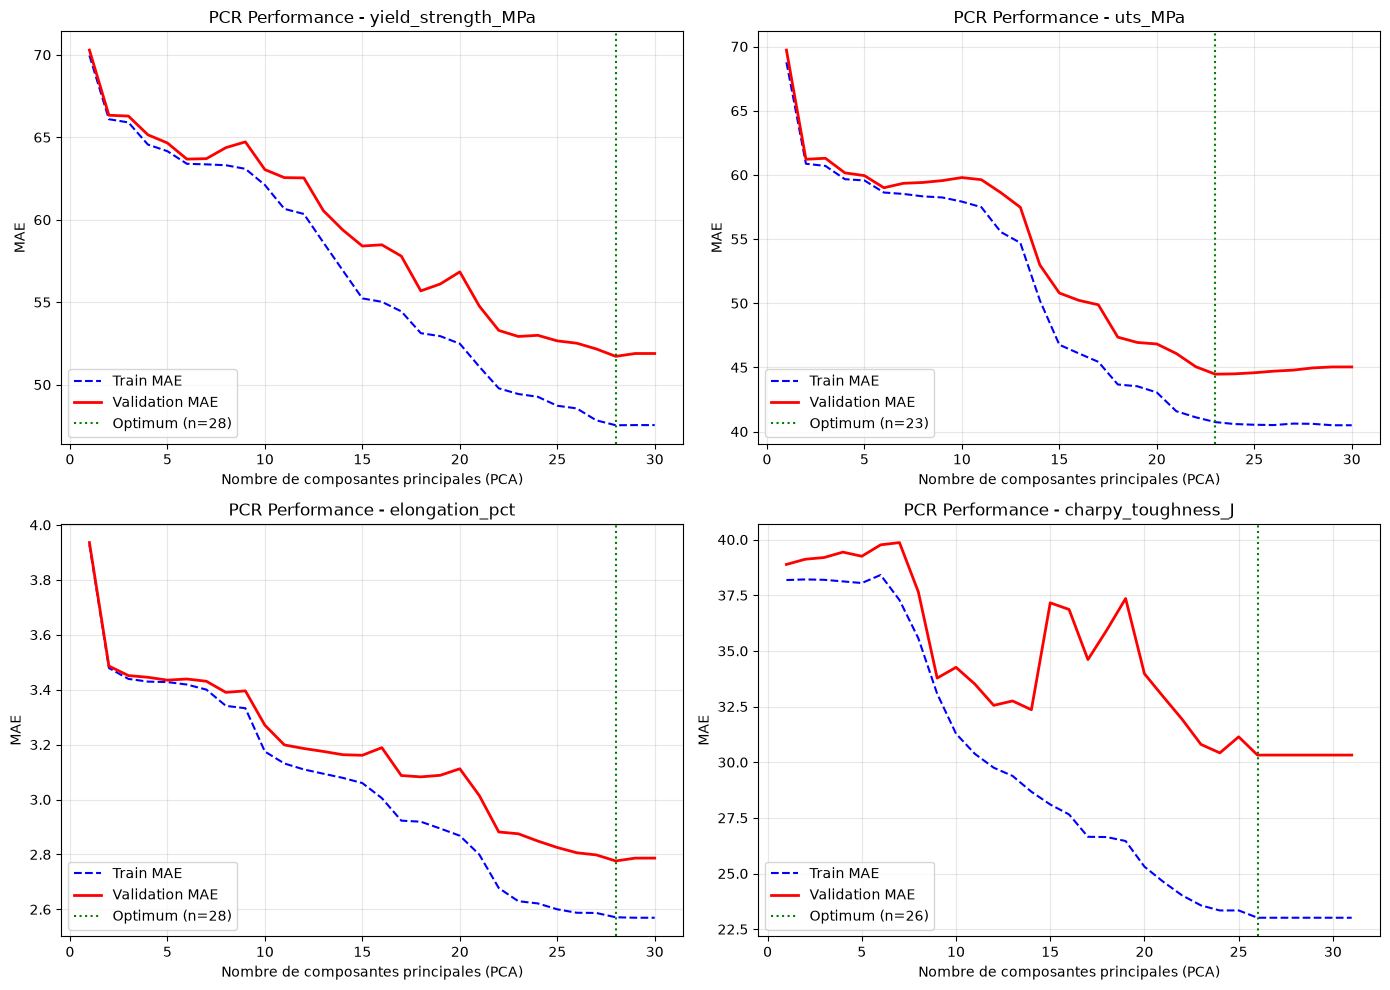

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, target in enumerate(TARGETS):
    df_hist = pcr_histories[target]
    opt_c = best_n_components[target]
    
    ax = axes[idx]
    ax.plot(df_hist["n_components"], df_hist["train_mae"], label="Train MAE", linestyle="--", color="blue")
    ax.plot(df_hist["n_components"], df_hist["val_mae"], label="Validation MAE", color="red", linewidth=2)
    ax.axvline(x=opt_c, color="green", linestyle=":", label=f"Optimum (n={opt_c})")
    
    ax.set_title(f"PCR Performance - {target}")
    ax.set_xlabel("Nombre de composantes principales (PCA)")
    ax.set_ylabel("MAE")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Évaluation finale et sauvegarde des résultats

In [21]:
pcr_results = evaluate("PCR", best_pcr_models, train)
pcr_results

,model,target,family,n,MAE,RMSE,MAE_std,RMSE_std,n_clf,n_nc,F1_nc,recall_nc
0,PCR,yield_strength_MPa,all,620,51.844643,69.495428,5.842369,6.574575,619,102,0.426667,0.313725
1,PCR,yield_strength_MPa,C-Mn,552,48.029445,63.559286,4.459066,3.298276,552,102,0.426667,0.313725
2,PCR,yield_strength_MPa,CrMo2,30,83.834266,114.362334,52.731809,64.579150,29,0,0.000000,0.000000
3,PCR,yield_strength_MPa,CrMo91,38,82.010447,98.946901,30.823726,30.626966,38,0,0.000000,0.000000
4,PCR,uts_MPa,all,596,44.549211,62.736173,4.731662,10.180172,595,198,0.604938,0.494949
5,PCR,uts_MPa,C-Mn,531,41.815064,55.379703,1.673857,1.838461,531,198,0.604938,0.494949
6,PCR,uts_MPa,CrMo2,34,68.138916,120.469662,59.403265,83.271212,33,0,0.000000,0.000000
7,PCR,uts_MPa,CrMo91,31,65.509921,84.963593,20.774693,30.907521,31,0,0.000000,0.000000
8,PCR,elongation_pct,all,558,2.777161,3.568780,0.241332,0.441346,557,48,0.285714,0.208333
9,PCR,elongation_pct,C-Mn,497,2.704923,3.426131,0.184827,0.282187,497,37,0.181818,0.108108


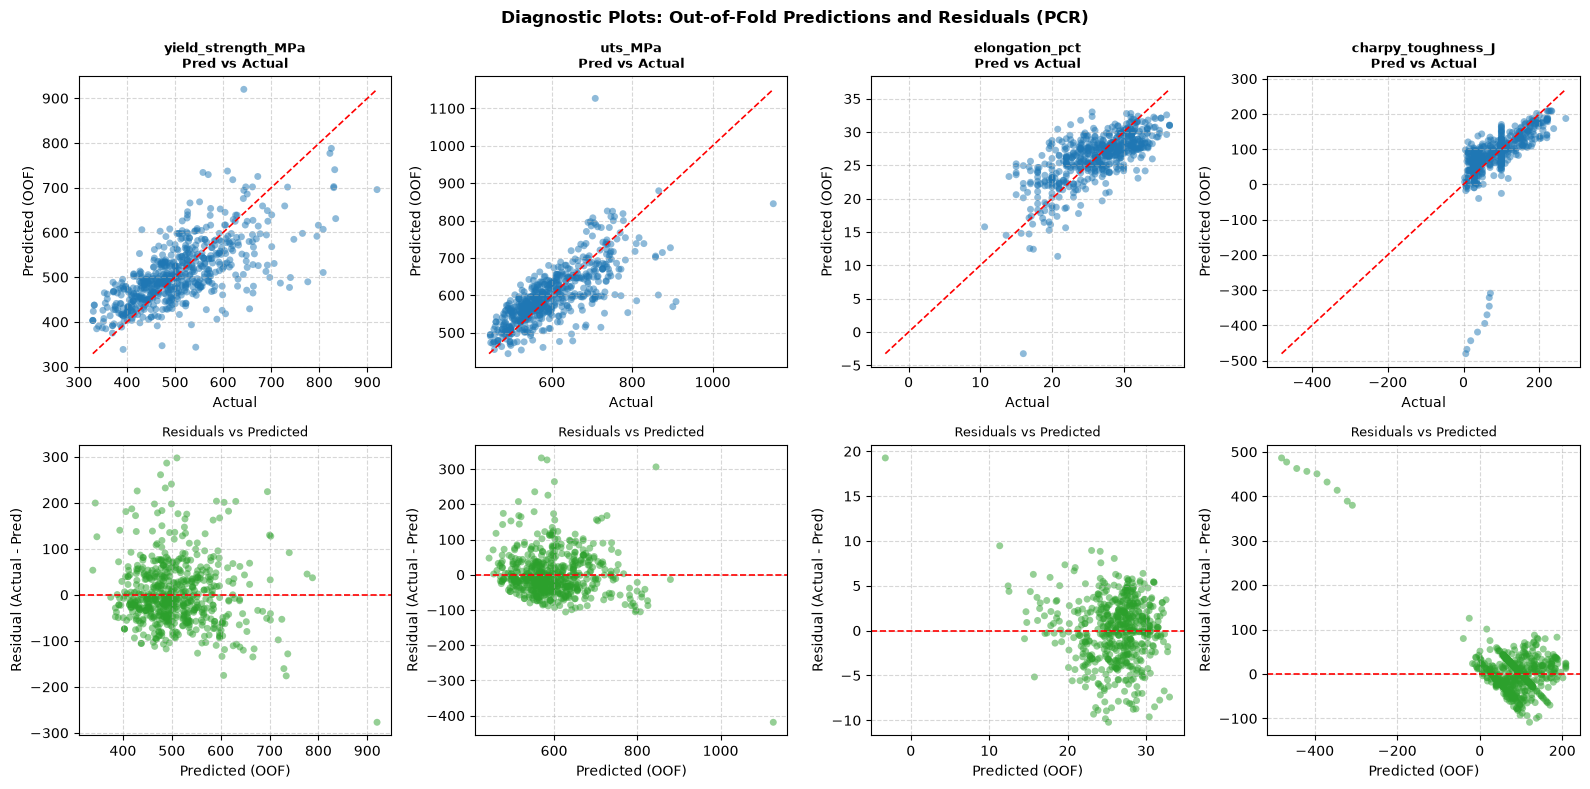

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, target in enumerate(TARGETS):
    X, y, _ = get_xy(train, target)
    oof_fwd = oof_predict(best_pcr_models[target], train, target)
    y_val = y.loc[oof_fwd.index]
    pred = oof_fwd["pred"]
    resids = y_val - pred
    
    ax_sc = axes[0, i]
    ax_sc.scatter(y_val, pred, alpha=0.5, edgecolors="none", s=25, color="#1f77b4")
    min_v, max_v = min(y_val.min(), pred.min()), max(y_val.max(), pred.max())
    ax_sc.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1.2)
    ax_sc.set_title(f"{target}\nPred vs Actual", fontsize=9, fontweight="bold")
    ax_sc.set_xlabel("Actual")
    ax_sc.set_ylabel("Predicted (OOF)")
    ax_sc.grid(True, linestyle="--", alpha=0.5)
    
    ax_res = axes[1, i]
    ax_res.scatter(pred, resids, alpha=0.5, edgecolors="none", s=25, color="#2ca02c")
    ax_res.axhline(0, color="r", linestyle="--", linewidth=1.2)
    ax_res.set_title("Residuals vs Predicted", fontsize=9)
    ax_res.set_xlabel("Predicted (OOF)")
    ax_res.set_ylabel("Residual (Actual - Pred)")
    ax_res.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Diagnostic Plots: Out-of-Fold Predictions and Residuals (PCR)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [23]:
# Enregistrement des résultats comparatifs
results = save_results(pcr_results)
models_to_compare = [
    "Baseline (mean)",
    "Linear regression",
    "Linear regression (forward)",
    "Linear regression (backward)",
    "PCR",
    "Pruned CART",
    "Bagging",
    "Random forest",
    "Extra-Trees"
]
compared = results[results["model"].isin(models_to_compare) & (results["family"] == "all")].set_index(["model", "target"])

print("--- Regression Metrics (MAE & RMSE) ---")
display(compared[["MAE", "RMSE"]].unstack().reindex(index=models_to_compare).reindex(columns=TARGETS, level="target").round(2))

print("\n--- Classification Metrics (F1_nc & recall_nc) ---")
display(compared[["F1_nc", "recall_nc"]].unstack().reindex(index=models_to_compare).reindex(columns=TARGETS + ["label"], level="target").round(2))

--- Regression Metrics (MAE & RMSE) ---


MAE                         \
target                       yield_strength_MPa uts_MPa elongation_pct   
model                                                                    
Baseline (mean)                           72.57   73.45           4.01   
Linear regression                         52.02   45.13           2.79   
Linear regression (forward)               50.26   42.43           2.72   
Linear regression (backward)              50.30   42.26           2.69   
PCR                                       51.84   44.55           2.78   
Pruned CART                               48.24   41.78           2.60   
Bagging                                   35.24   30.86           1.95   
Random forest                             33.95   29.55           1.94   
Extra-Trees                               29.08   25.24           1.78   

                                                              RMSE          \
target                       charpy_toughness_J yield_strength_MPa uts_MPa   
model                                                                        
Baseline (mean)                           39.89              94.41   92.19   
Linear regression                         30.36              69.67   63.01   
Linear regression (forward)               25.14              67.34   59.00   
Linear regression (backward)              25.29              67.36   58.88   
PCR                                       30.36              69.50   62.74   
Pruned CART                               18.87              66.22   59.97   
Bagging                                   19.11              49.40   44.45   
Random forest                             19.09              47.46   42.30   
Extra-Trees                               17.37              42.49   38.84   

                                                                
target                       elongation_pct charpy_toughness_J  
model                                                           
Baseline (mean)                        4.85              51.73  
Linear regression                      3.60              58.54  
Linear regression (forward)            3.50              32.11  
Linear regression (backward)           3.47              31.99  
PCR                                    3.57              58.54  
Pruned CART                            3.32              32.46  
Bagging                                2.51              28.16  
Random forest                          2.51              28.39  
Extra-Trees                            2.36              27.71


--- Classification Metrics (F1_nc & recall_nc) ---


F1_nc                         \
target                       yield_strength_MPa uts_MPa elongation_pct   
model                                                                    
Baseline (mean)                            0.00    0.00           0.00   
Linear regression                          0.45    0.57           0.31   
Linear regression (forward)                0.35    0.60           0.30   
Linear regression (backward)               0.40    0.60           0.30   
PCR                                        0.43    0.60           0.29   
Pruned CART                                0.60    0.64           0.46   
Bagging                                    0.68    0.67           0.62   
Random forest                              0.63    0.68           0.59   
Extra-Trees                                0.78    0.74           0.72   

                                                               recall_nc  \
target                       charpy_toughness_J label yield_strength_MPa   
model                                                                      
Baseline (mean)                            0.00  0.00               0.00   
Linear regression                          0.65  0.52               0.33   
Linear regression (forward)                0.67  0.58               0.25   
Linear regression (backward)               0.75  0.59               0.28   
PCR                                        0.65  0.53               0.31   
Pruned CART                                0.52  0.77               0.60   
Bagging                                    0.17  0.81               0.57   
Random forest                              0.26  0.76               0.48   
Extra-Trees                                0.27  0.84               0.65   

                                                                              
target                       uts_MPa elongation_pct charpy_toughness_J label  
model                                                                         
Baseline (mean)                 0.00           0.00               0.00  0.00  
Linear regression               0.47           0.23               0.55  0.39  
Linear regression (forward)     0.49           0.23               0.52  0.43  
Linear regression (backward)    0.49           0.23               0.62  0.45  
PCR                             0.49           0.21               0.55  0.40  
Pruned CART                     0.63           0.50               0.62  0.81  
Bagging                         0.56           0.50               0.10  0.72  
Random forest                   0.54           0.44               0.17  0.64  
Extra-Trees                     0.61           0.60               0.17  0.72

La régression avec les principales composantes n'améliorent pas une régression linéaire. Toutes les features sont sans doute représentées par les composantes principales utilisées pour la régression.